In [1]:
%load_ext autoreload
%autoreload 2

# RNN Model Training

In [7]:
import sys
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# set up relative imports
project_folder = Path.cwd().parent.parent.parent
sys.path.append(str(project_folder))

In [9]:
from modeling.model.lstm import create_lstm_model, get_callbacks
from modeling.utilities.data_prep import setup_sequential_data

#### read in data

In [10]:
data_folder = Path(r'..\..\data\model-ready\water-weather')

# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'scaled-Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y_df = pd.read_parquet(data_folder / 'scaled-Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y_df = pd.read_parquet(data_folder / 'scaled-Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [11]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

#### set up sequential data

In [12]:
# train
train_X_df.reset_index(drop=True, inplace=True)
train_y_df.reset_index(drop=True, inplace=True)

# test
test_X_df.reset_index(drop=True, inplace=True)
test_y_df.reset_index(drop=True, inplace=True)

# val
val_X_df.reset_index(drop=True, inplace=True)
val_y_df.reset_index(drop=True, inplace=True)

In [13]:
seq_size = 10
X_train, y_train, y_idx_train = setup_sequential_data(train_X_df, train_y_df, seq_size)
X_val, y_val, y_idx_val =  setup_sequential_data(val_X_df, val_y_df, seq_size)
X_test, y_test, y_idx_test =  setup_sequential_data(test_X_df, test_y_df, seq_size)

In [14]:
X_test.shape

(4731, 10, 16)

### Compile and Train the model

In [15]:
input_shape = (X_train.shape[1], X_train.shape[2])

In [16]:
model = create_lstm_model(input_shape)

In [17]:
model.compile(optimizer='adam', loss='mse',)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        13,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,651 (131.45 KB)

 Trainable params: 33,651 (131.45 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, 
          y_train, 
          epochs=100, 
          batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=get_callbacks()
          )

Epoch 1/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 22.2635 - val_loss: 7.5585 - learning_rate: 0.0010
Epoch 2/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5.7456 - val_loss: 1.3655 - learning_rate: 0.0010
Epoch 3/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 2.6625 - val_loss: 0.8787 - learning_rate: 0.0010
Epoch 4/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 2.1995 - val_loss: 0.5800 - learning_rate: 0.0010
Epoch 5/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2.0938 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 6/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2.0266 - val_loss: 0.5771 - learning_rate: 0.0010
Epoch 7/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.9505 - val_loss: 0.4968 - learning_rate: 0.0010
Epoch 8/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 1.9389 - val_loss: 0.4123 - learning_rate: 0.0010
Epoch 9/100
691/691 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.8601 - val_loss: 0.8719 - learning_r

#### Evaluate the model

In [20]:
y_pred = model.predict(X_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


In [21]:
test_x_unscaled = scaler.inverse_transform(test_X_df)
test_x_df = pd.DataFrame(columns=test_X_df.columns, data=test_x_unscaled)

In [22]:
test_x_df.shape

(4740, 16)

In [23]:
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred.flatten()
}, index=y_idx_test)

In [24]:
results_df

,actual,predicted
9,13.10,13.555499
10,13.70,13.452515
11,13.90,13.708123
12,13.90,13.894490
13,13.40,13.870821
...,...,...
4735,17.25,16.848440
4736,17.10,16.799955
4737,17.20,16.742590
4738,17.10,16.808556


In [25]:
test_x_df = test_x_df.join(results_df,
                how='inner')

In [26]:
# this date recreation is imperfect because of how we encoded day
test_x_df['date'] = pd.to_datetime(test_x_df[['year','month','day']], errors='coerce')

In [27]:
test_x_df['errors'] = test_x_df.predicted - test_x_df.actual

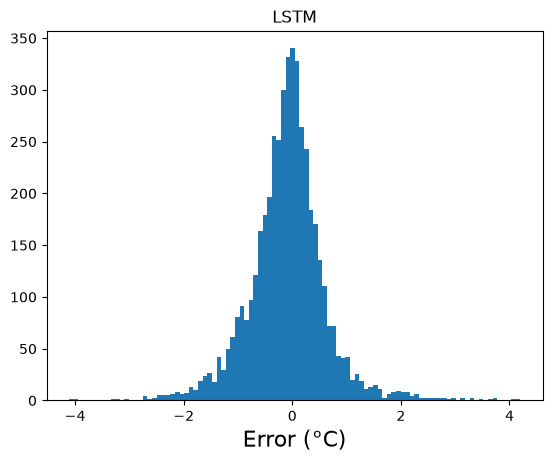

In [28]:
plt.hist(test_x_df.errors, bins='auto')
plt.title('LSTM')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [29]:
pd.DataFrame(test_x_df.errors.abs().describe()).T.round(3)

,count,mean,std,min,25%,50%,75%,max
errors,4731.0,0.501,0.501,0.0,0.153,0.352,0.674,4.197


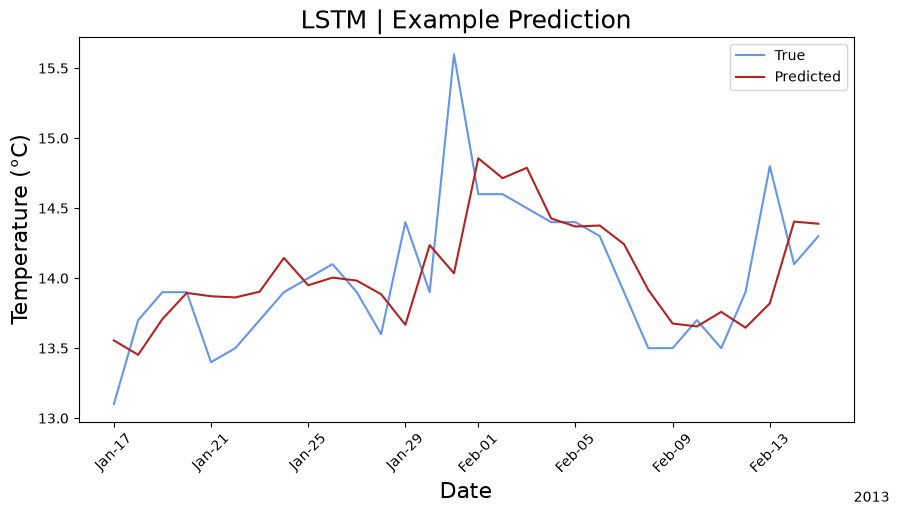

In [30]:
plot_df = test_x_df[:30].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.actual, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.predicted, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('LSTM | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.tick_params(axis='x', labelrotation=45)
fig.text(.9, -.05, f'{int(plot_df.year.unique()[0])}')
plt.show()

In [34]:
errors = test_x_df.errors

In [35]:
mae = abs(errors).mean()
mse = np.mean([errors**2])
rmse = np.sqrt(mse)
r_2 = r2_score(y_test, y_pred)
print(f'MAE = {round(mae, 2)}')
print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

MAE = 0.5
RMSE = 0.71
r2 score = 0.94


##### RMSE and R2 Score are 0.71 and 0.94 respectively for the LSTM model trained on the no wind dataset. This is actually worse than our baseline linear regression model

In [36]:
output_folder = Path(r"C:\Users\speco\USD\10_capstone\src\modeling\data\test-results\no-wind")
output_file_name = 'LSTM-model-test-results.csv'
output_path = output_folder / output_file_name

test_X_df.to_csv(output_path, index=False)